# 🖼️ Image Generation with Diffusion Models

---

## 🔹 What are Diffusion Models?
- Generative AI models that create images by **gradually denoising random noise** into a coherent picture.  
- They learn to **reverse the process of adding noise**:  
  - *Forward*: Start with an image → add noise until it becomes pure noise.  
  - *Reverse*: Start with noise → progressively denoise into a meaningful image.

---

## 🔹 How They Work
1. **Training Phase**
   - Model learns how images degrade into noise (*forward process*).
   - Trains to predict and remove noise (*reverse process*).

2. **Generation Phase**
   - Start with random noise.
   - Iteratively apply the model to denoise.
   - After many steps → realistic image that matches a prompt or condition.

---

## 🔹 Key Features
- **High quality & diversity** of outputs.  
- **Conditioning**: guided by text prompts, class labels, or other inputs.  
- **Step-based refinement**, making the process interpretable.  

---

## 🔹 Popular Models
- **Stable Diffusion** (Stability AI) – open-source text-to-image.  
- **DALL·E 3** (OpenAI) – advanced text-to-image generation.  
- **Imagen** (Google) – high fidelity image synthesis.  

---

### 👉 In short:
**Diffusion models generate images by starting with noise and progressively refining it into realistic outputs, guided by training and often conditioned on prompts.**


### 1. Loading the text-to-image model with Pipeline

In [4]:
!pip install diffusers transformers accelerate safetensors torch matplotlib --upgrade -q

import torch
from diffusers import AutoPipelineForText2Image
import matplotlib.pyplot as plt

# Load pipeline in CPU mode
pipeline = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float32  # CPU must use float32
).to("cpu")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


### 2. Generating Images

  0%|          | 0/2 [00:00<?, ?it/s]

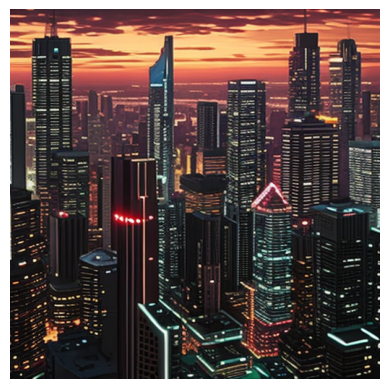

In [8]:
prompt = "A futuristic cityscape at sunset, ultra-detailed, cinematic lighting"

image1 = pipeline(
    prompt=prompt,
    num_inference_steps=2,
    guidance_scale=0.0,
    width=512,
    height=512
).images[0]

# Show image
plt.imshow(image1)
plt.axis("off")
plt.show()

  0%|          | 0/2 [00:00<?, ?it/s]

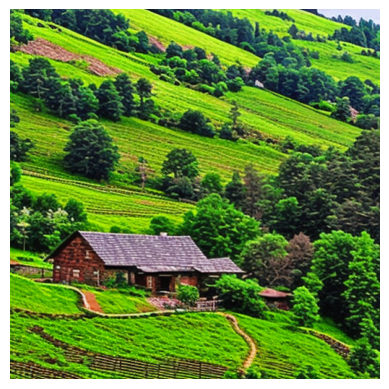

In [9]:
prompt = "A farmhouse in the middle of a lush green forest valley"

image2 = pipeline(
    prompt=prompt,
    num_inference_steps=2,
    guidance_scale=0.0,
    width=512,
    height=512
).images[0]

# Show image
plt.imshow(image2)
plt.axis("off")
plt.show()

In [12]:
image1.save("cityscape.png")
image2.save("farmhouse.png")

### 3. Loading img-to-text model

In [10]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from PIL import Image
import requests
import torch

# Load model, processor, tokenizer
model_name = "nlpconnect/vit-gpt2-image-captioning"
model = VisionEncoderDecoderModel.from_pretrained(model_name)
feature_extractor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

### 4. Image Captioning

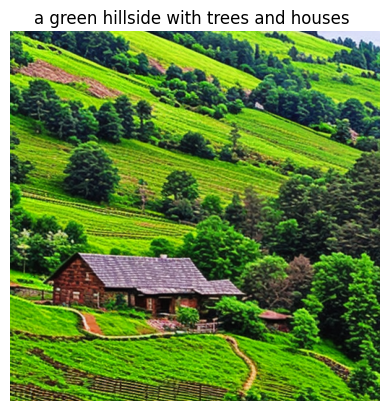

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

# Load the saved generated image
img = Image.open("farmhouse.png").convert("RGB")

# Preprocess for captioning
pixel_values = feature_extractor(images=img, return_tensors="pt").pixel_values.to(device)

# Generate caption
output_ids = model.generate(pixel_values, max_length=50, num_beams=4)
caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Show image with caption
plt.imshow(img)
plt.axis("off")
plt.title(caption, fontsize=12, wrap=True)
plt.show()


## Discussion & Summary

### 1. Model Choice
I used **`stabilityai/sd-turbo`**  for image generation because it is lighter and more CPU-friendly than larger models like Stable Diffusion XL.  
For image-to-text captioning, I used **`nlpconnect/vit-gpt2-image-captioning`**, a free and lightweight model that works efficiently on CPU.

---

### 2. Prompts & Parameters
- **Prompt:**  
  *"A farmhouse in the middle of a lush green forest valley"*  

- **Generation Parameters:**  
  - `num_inference_steps = 2` → speeds up generation on CPU  
  - `guidance_scale = 0.0` → allows more creativity  
  - `width = 512`, `height = 512` → balanced resolution for clarity and speed  

---

### 3. Observations
- The generated image captured the farmhouse and greenery fairly well.  
- With only 2 inference steps, the output was fast but slightly blurry and less detailed.  
- The captioning model produced a relevant but somewhat generic description.  
- Increasing inference steps improves realism but takes more time on CPU.

---

### 4. Challenges & Findings
- Running diffusion models on **CPU** is significantly slower than on GPU.  
- Reducing inference steps helps speed but lowers quality.  
- Captioning models tend to describe the main objects correctly but miss finer details.  
- Combining generation and captioning creates a simple but effective **prompt → image → caption** pipeline.
